Wynik R^2: 0.05
Błąd MAE: 1.28

Wpływ poszczególnych zmiennych:
             Współczynnik (Waga)
avg_stress              0.275392
sleep_score             0.022893
steps                   0.000126
SYS                    -0.007869
avg_hr_x               -0.163001


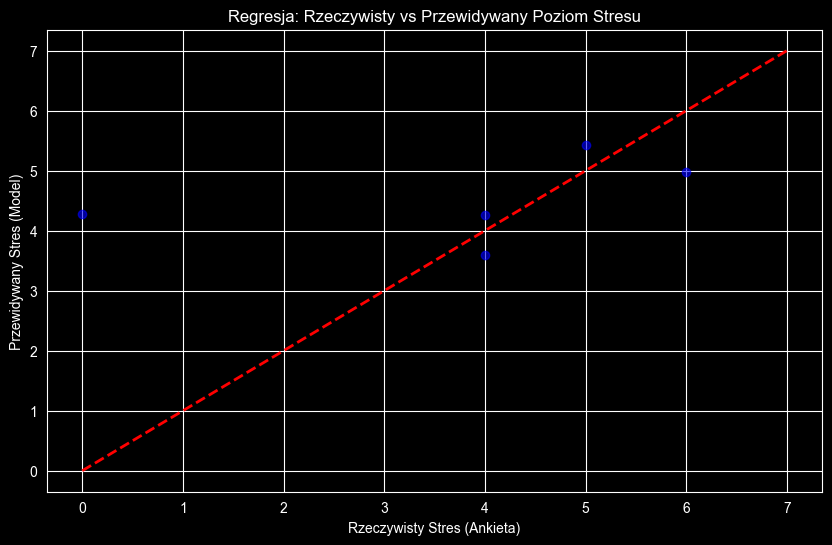

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Przygotowanie danych
df = pd.read_csv('../data/merged_data/merged_master_df.csv')

# Wybieramy zmienne objaśniające (X) i zmienną objaśnianą (y)
features = ['avg_hr_x', 'avg_stress', 'sleep_score', 'SYS', 'steps']
target = 'Stres'

# Skupiamy się na danych bez NaN
df_reg = df[features + [target]].dropna()

X = df_reg[features]
y = df_reg[target]

# 2. Podział na zbiór treningowy (80%) i testowy (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Budowa i trenowanie modelu
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Przewidywania
y_pred = model.predict(X_test)

# 5. Metryki i interpretacja
print(f"Wynik R^2: {r2_score(y_test, y_pred):.2f}")
print(f"Błąd MAE: {mean_absolute_error(y_test, y_pred):.2f}")

# Wyświetlenie wag (Co najbardziej wpływa na stres?)
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Współczynnik (Waga)'])
print("\nWpływ poszczególnych zmiennych:")
print(coeff_df.sort_values(by='Współczynnik (Waga)', ascending=False))

# 6. Wykres: Rzeczywistość vs Przewidywania
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Linia idealnego dopasowania
plt.xlabel('Rzeczywisty Stres (Ankieta)')
plt.ylabel('Przewidywany Stres (Model)')
plt.title('Regresja: Rzeczywisty vs Przewidywany Poziom Stresu')
plt.grid(True)
plt.show()

Liczba dni z wypełnioną ankietą: 53


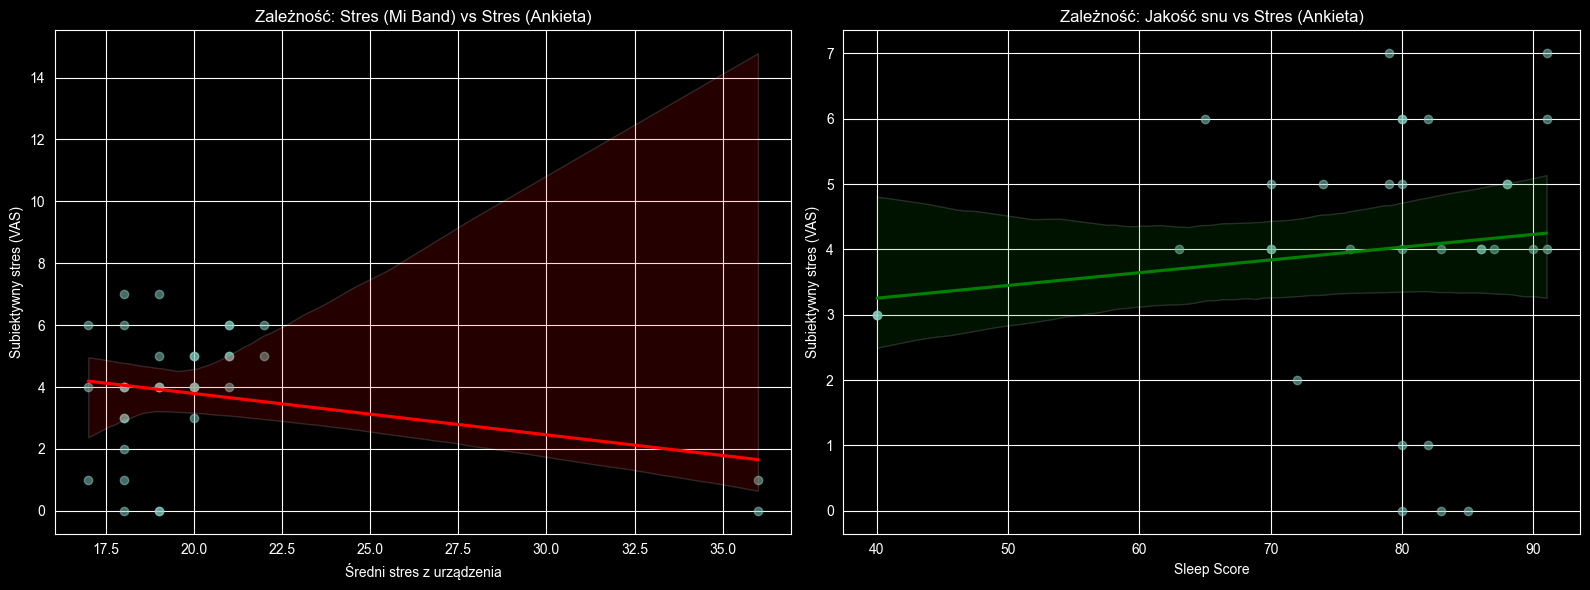

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Wczytanie danych
df = pd.read_csv('../data/merged_data/merged_master_df.csv')

# 2. Filtrowanie: Skupiamy się TYLKO na dniach z wypełnioną ankietą stresu
df_survey = df[df['Stres'].notna()].copy()

print(f"Liczba dni z wypełnioną ankietą: {len(df_survey)}")

# 3. Wizualizacja dwóch kluczowych zależności
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Wykres A: Stres z zegarka vs Stres z ankiety
sns.regplot(x='avg_stress', y='Stres', data=df_survey, ax=axes[0],
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
axes[0].set_title('Zależność: Stres (Mi Band) vs Stres (Ankieta)')
axes[0].set_xlabel('Średni stres z urządzenia')
axes[0].set_ylabel('Subiektywny stres (VAS)')

# Wykres B: Jakość snu vs Stres z ankiety
sns.regplot(x='sleep_score', y='Stres', data=df_survey, ax=axes[1],
            scatter_kws={'alpha':0.5}, line_kws={'color':'green'})
axes[1].set_title('Zależność: Jakość snu vs Stres (Ankieta)')
axes[1].set_xlabel('Sleep Score')
axes[1].set_ylabel('Subiektywny stres (VAS)')

plt.tight_layout()
plt.show()

--- WYNIKI MODELU LASU LOSOWEGO ---
Współczynnik R^2: 0.1395
Błąd MAE: 1.04
Błąd RMSE: 1.89


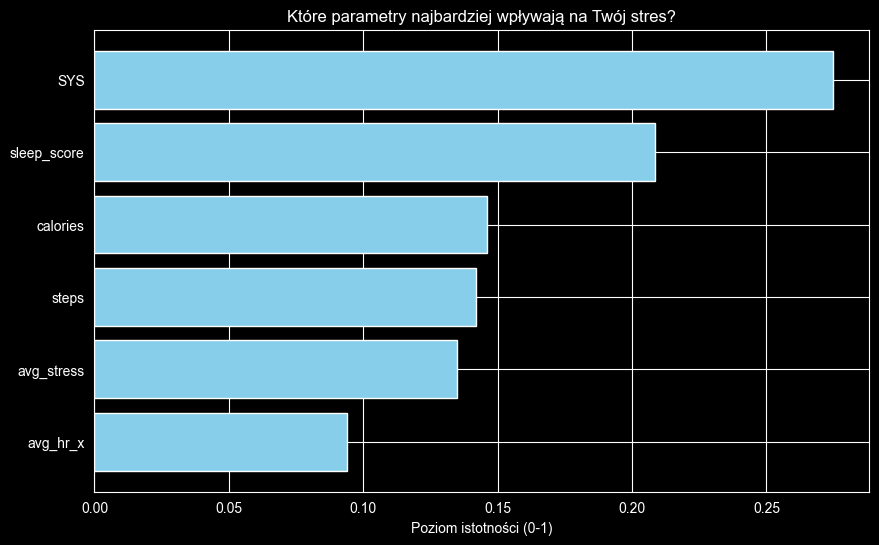

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# 1. Przygotowanie danych
df = pd.read_csv('../data/merged_data/merged_master_df.csv')

# Filtrowanie: tylko dni z wynikiem ankiety (Target)
df_reg = df[df['Stres'].notna()].copy()

# Wybór cech (Features) na podstawie korelacji (wybieramy te z najwyższym r)
# Uwaga: jeśli Twoja skala to 0-10, a chcesz 0-100, możesz przemnożyć: df_reg['Stres'] * 10
features = ['avg_stress', 'avg_hr_x', 'sleep_score', 'SYS', 'steps', 'calories']

# Usuwamy NaN z cech wejściowych, aby model mógł pracować
df_clean = df_reg[features + ['Stres']].dropna()

X = df_clean[features]
y = df_clean['Stres']

# 2. Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Model: Random Forest (Lasy Losowe)
# Ustawiamy n_estimators=100 (100 drzew decyzyjnych)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Predykcja i Ewaluacja
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"--- WYNIKI MODELU LASU LOSOWEGO ---")
print(f"Współczynnik R^2: {r2:.4f}")
print(f"Błąd MAE: {mae:.2f}")
print(f"Błąd RMSE: {rmse:.2f}")

# 5. ISTOTNOŚĆ CECH (Feature Importance)
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({'Cecha': features, 'Istotność': importances})
feature_importance_df = feature_importance_df.sort_values(by='Istotność', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Cecha'], feature_importance_df['Istotność'], color='skyblue')
plt.xlabel('Poziom istotności (0-1)')
plt.title('Które parametry najbardziej wpływają na Twój stres?')
plt.gca().invert_yaxis()
plt.show()

In [6]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Przygotowanie danych
df = pd.read_csv('../data/merged_data/merged_master_df.csv')
features = ['avg_stress', 'avg_hr_x', 'sleep_score', 'SYS', 'steps', 'calories']
df_clean = df[df['Stres'].notna()][features + ['Stres']].dropna()

X = df_clean[features]
y = df_clean['Stres']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Definicja "Siatki" parametrów do sprawdzenia
param_grid = {
    'n_estimators': [50, 100, 200],      # Liczba drzew
    'max_depth': [None, 5, 10, 20],      # Głębokość drzew
    'min_samples_split': [2, 5, 10],     # Min. liczba próbek do podziału węzła
    'bootstrap': [True, False]           # Czy używać losowych podzbiorów
}

# 3. Uruchomienie Grid Search z walidacją krzyżową (cv=5)
rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=5, n_jobs=-1, scoring='neg_mean_absolute_error')

grid_search.fit(X_train, y_train)

# 4. Najlepszy model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print(f"Najlepsze parametry: {grid_search.best_params_}")
print(f"Nowy R^2: {r2_score(y_test, y_pred):.4f}")
print(f"Nowy MAE: {mean_absolute_error(y_test, y_pred):.2f}")

# 5. Porównanie: Rzeczywiste vs Przewidziane (Top 10 wyników)
comparison = pd.DataFrame({'Rzeczywisty Stres': y_test, 'Przewidziany': y_pred})
print("\nPrzykładowe dopasowanie:")
print(comparison.head(10))

Najlepsze parametry: {'bootstrap': True, 'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}
Nowy R^2: 0.0099
Nowy MAE: 1.24

Przykładowe dopasowanie:
     Rzeczywisty Stres  Przewidziany
288                6.0      4.792517
301                4.0      4.008990
248                0.0      4.347072
331                4.0      3.829787
294                5.0      4.542687
